# Logdet Method Profiling Across Matrix Sizes

This notebook profiles the runtime of different log-determinant strategies used in bayespecon:

- `exact`: symbolic determinant route
- `eigenvalue`: spectral precompute route
- `grid`: spline interpolation over a precomputed grid
- `full`: sparse-LU grid (MATLAB-style `lndetfull`)
- `int`: sparse-LU + spline interpolation (MATLAB-style `lndetint`)
- `mc`: Monte Carlo trace approximation (MATLAB-style `lndetmc`)
- `ichol`: ILU-based approximation (MATLAB-style `lndetichol` analog)

For each matrix size, we report:

- **setup time**: build + compile callable logdet function
- **evaluation time**: average cost to evaluate at many rho values

In [1]:
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytensor
import pytensor.tensor as pt

from bayespecon.logdet import make_logdet_fn

In [2]:
def make_line_w(n: int) -> np.ndarray:
    """Create a row-standardized line-lattice W matrix."""
    W = np.zeros((n, n), dtype=np.float64)
    idx = np.arange(n)
    W[idx[1:], idx[:-1]] = 1.0
    W[idx[:-1], idx[1:]] = 1.0
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0.0] = 1.0
    return W / row_sums


def compile_logdet_callable(W: np.ndarray, method: str):
    """Return a compiled callable f(rho) and its setup time in seconds."""
    t0 = time.perf_counter()
    rho = pt.scalar('rho')
    expr = make_logdet_fn(W, method=method, rho_min=-0.95, rho_max=0.95)(rho)
    fn = pytensor.function([rho], expr)
    setup_s = time.perf_counter() - t0
    return fn, setup_s


def bench_eval_seconds(fn, rhos: np.ndarray, repeats: int = 5) -> float:
    """Median per-call evaluation latency in microseconds."""
    run_times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        for r in rhos:
            _ = fn(float(r))
        elapsed = time.perf_counter() - t0
        run_times.append(elapsed / len(rhos))
    return float(np.median(run_times))

In [9]:
@dataclass
class ProfileConfig:
    # Include larger sizes to expose high-n behavior.
    sizes: tuple[int, ...] = (40, 80, 120, 180, 260, 360, 520, 720, 1000, 2000, 5000, 10000)
    methods: tuple[str, ...] = ('exact', 'eigenvalue', 'grid', 'full', 'int', 'mc', 'ichol')
    method_max_n: dict = None
    eval_points: int = 80
    eval_repeats: int = 3

    def __post_init__(self):
        if self.method_max_n is None:
            # Practical safety caps for this dense benchmark setup.
            # - exact grows quickly, keep only small n
            # - grid allocates an n_grid x n x n tensor internally
            # - eigenvalue requires dense eigendecomposition
            # - full/int/ichol use sparse factorizations across rho grid
            # - mc uses stochastic trace approximation
            self.method_max_n = {
                'exact': 120,
                'eigenvalue': 2000,
                'grid': 1000,
                'full': 1000,
                'int': 1000,
                'mc': 5000,
                'ichol': 5000,
            }


cfg = ProfileConfig()
rho_grid = np.linspace(-0.9, 0.9, cfg.eval_points)
results = []
skipped = []

for n in cfg.sizes:
    W = make_line_w(n)
    print(f'Profiling n={n}...')
    for method in cfg.methods:
        if n > cfg.method_max_n[method]:
            skipped.append({'n': n, 'method': method, 'reason': 'above method_max_n cap'})
            continue
        try:
            fn, setup_s = compile_logdet_callable(W, method)
            eval_s = bench_eval_seconds(fn, rho_grid, repeats=cfg.eval_repeats)
            results.append({
                'n': n,
                'method': method,
                'setup_ms': 1e3 * setup_s,
                'eval_us': 1e6 * eval_s,
            })
        except Exception as exc:
            skipped.append({'n': n, 'method': method, 'reason': f'failed: {type(exc).__name__}: {exc}'})

res = pd.DataFrame(results).sort_values(['method', 'n']).reset_index(drop=True)
if not res.empty:
    # Total cost for a full rho sweep used in this notebook.
    res['total_ms'] = res['setup_ms'] + (res['eval_us'] * cfg.eval_points / 1e3)
res

Profiling n=40...
Profiling n=80...
Profiling n=120...
Profiling n=180...
Profiling n=260...
Profiling n=360...
Profiling n=520...
Profiling n=720...
Profiling n=1000...
Profiling n=2000...
Profiling n=5000...
Profiling n=10000...


,n,method,setup_ms,eval_us,total_ms
0,40,eigenvalue,8.725542,3.092713,8.972959
1,80,eigenvalue,7.092417,2.781244,7.314917
2,120,eigenvalue,7.662125,2.914586,7.895292
3,180,eigenvalue,12.957792,3.208849,13.214500
4,260,eigenvalue,19.429167,3.355206,19.697583
...,...,...,...,...,...
57,520,mc,41.710334,3.063015,41.955375
58,720,mc,44.790250,3.057811,45.034875
59,1000,mc,46.359708,3.071351,46.605416
60,2000,mc,62.186958,3.054168,62.431292


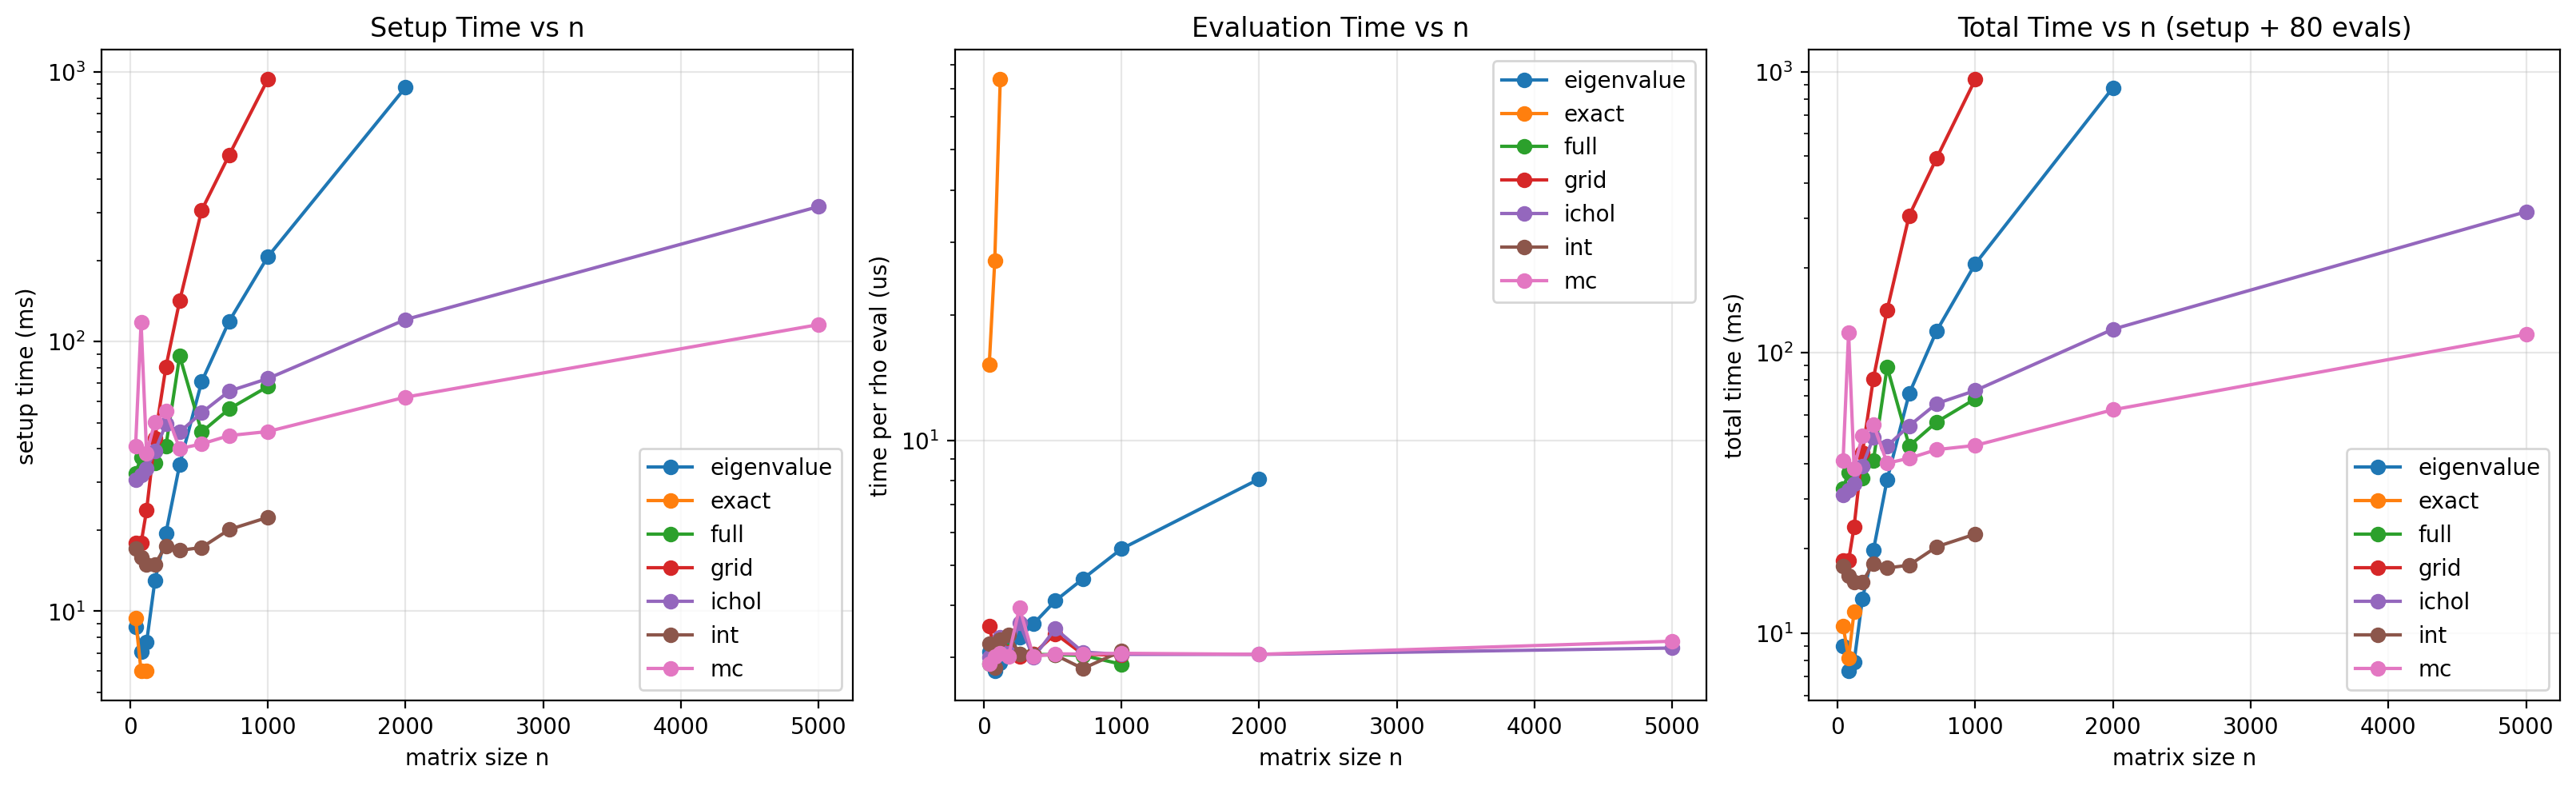

In [10]:
if res.empty:
    raise RuntimeError('No profiling results were generated.')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for method, grp in res.groupby('method'):
    grp = grp.sort_values('n')
    axes[0].plot(grp['n'], grp['setup_ms'], marker='o', label=method)
    axes[1].plot(grp['n'], grp['eval_us'], marker='o', label=method)
    axes[2].plot(grp['n'], grp['total_ms'], marker='o', label=method)

axes[0].set_title('Setup Time vs n')
axes[0].set_xlabel('matrix size n')
axes[0].set_ylabel('setup time (ms)')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Evaluation Time vs n')
axes[1].set_xlabel('matrix size n')
axes[1].set_ylabel('time per rho eval (us)')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

axes[2].set_title(f'Total Time vs n (setup + {cfg.eval_points} evals)')
axes[2].set_xlabel('matrix size n')
axes[2].set_ylabel('total time (ms)')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.show()

In [5]:
summary = (
    res.pivot_table(index='n', columns='method', values=['setup_ms', 'eval_us', 'total_ms'])
       .sort_index()
)
display(summary)

if skipped:
    skipped_df = pd.DataFrame(skipped).sort_values(['n', 'method']).reset_index(drop=True)
    print('Skipped combinations (due to safety caps or failures):')
    display(skipped_df)

eval_us                                                     \
method eigenvalue      exact      full      grid     ichol       int   
n                                                                      
40       2.584374  13.195316  3.435928  3.038533  3.220828  3.385940   
80       3.005727  27.247402  2.951047  3.232807  3.099488  3.163540   
120      3.226043  50.255202  3.114576  3.053120  3.465614  3.190630   
180      3.719272        NaN  2.886471  3.055204  3.247394  3.154681   
260      3.489584        NaN  3.192702  3.124995  3.418222  3.117719   
360      3.708841        NaN  3.029685  3.140629  3.243238  3.141141   
520      4.164584        NaN  3.228639  3.401039  3.228127  3.230723   
720      5.053636        NaN  3.102596  3.175519  3.069779  3.227079   
1000     6.071362        NaN  3.034889  3.290095  3.155204  3.048440   
2000     8.665619        NaN       NaN       NaN  3.096357       NaN   
5000          NaN        NaN       NaN       NaN       NaN       NaN   

                    setup_ms                          ...              \
method        mc  eigenvalue       exact        full  ...       ichol   
n                                                     ...               
40      3.080210   18.307333  720.903500  701.297625  ...   45.554167   
80      3.305729    7.009541    6.623126   45.173543  ...   33.152166   
120     3.208860    8.623875    6.628876   46.531542  ...   35.185333   
180     3.163528   13.132292         NaN   48.810292  ...   52.614541   
260     3.163540   19.868666         NaN   49.705250  ...   41.358459   
360     3.177603   32.022875         NaN   55.787708  ...   44.009083   
520     3.278651   71.712416         NaN   61.906083  ...   52.081125   
720     2.920313  116.631625         NaN   69.268125  ...   60.597084   
1000    3.138534  200.631166         NaN   80.193000  ...   67.121000   
2000    3.192190  866.069250         NaN         NaN  ...  131.747500   
5000    3.168755         NaN         NaN         NaN  ...         NaN   

                                  total_ms                          \
method         int          mc  eigenvalue       exact        full   
n                                                                    
40      507.207041   29.431708   18.514083  721.959125  701.572499   
80       24.671792   30.250959    7.249999    8.802918   45.409626   
120      25.953834   31.021917    8.881958   10.649292   46.780708   
180      26.938375   33.321917   13.429834         NaN   49.041210   
260      26.155165   32.430584   20.147833         NaN   49.960666   
360      52.665957   34.424835   32.319582         NaN   56.030083   
520      40.038750   79.852042   72.045582         NaN   62.164375   
720      32.728543   39.625541  117.035916         NaN   69.516333   
1000     33.584042   41.323249  201.116875         NaN   80.435791   
2000           NaN   51.870125  866.762499         NaN         NaN   
5000           NaN  112.065418         NaN         NaN         NaN   

                                                        
method        grid       ichol         int          mc  
n                                                       
40      131.505458   45.811833  507.477916   29.678125  
80       17.598166   33.400125   24.924875   30.515417  
120      24.352834   35.462582   26.209084   31.278626  
180      41.018500   52.874332   27.190750   33.574999  
260      74.981332   41.631917   26.404583   32.683667  
360     116.043708   44.268542   52.917249   34.679043  
520     278.434875   52.339375   40.297207   80.114334  
720     510.139666   60.842667   32.986709   39.859166  
1000    996.130875   67.373416   33.827917   41.574332  
2000           NaN  131.995209         NaN   52.125501  
5000           NaN         NaN         NaN  112.318918  

[11 rows x 21 columns]

Skipped combinations (due to safety caps or failures):


,n,method,reason
0,180,exact,above method_max_n cap
1,260,exact,above method_max_n cap
2,360,exact,above method_max_n cap
3,520,exact,above method_max_n cap
4,720,exact,above method_max_n cap
5,1000,exact,above method_max_n cap
6,2000,exact,above method_max_n cap
7,2000,full,above method_max_n cap
8,2000,grid,above method_max_n cap
9,2000,int,above method_max_n cap


## Coefficient and Fit-Time Comparison Across Logdet Methods

This section estimates the same SAR model using each `logdet_method` and compares:

- posterior mean coefficients (`rho`, `beta_0`, `beta_1`, `beta_2`)
- total wall-clock time to estimate each model

To keep this section runnable in docs contexts, sampling is intentionally modest.

In [8]:
import pymc as pm


def simulate_sar_data(n: int = 80, seed: int = 2026):
    """Simulate a small SAR dataset for method comparison."""
    rng = np.random.default_rng(seed)
    W = make_line_w(n)

    X = np.column_stack(
        [
            np.ones(n, dtype=np.float64),
            rng.normal(size=n),
            rng.normal(size=n),
        ]
    )
    beta_true = np.array([1.0, 0.8, -0.5], dtype=np.float64)
    rho_true = 0.35
    sigma_true = 0.7

    # y = (I - rho W)^(-1) (X beta + eps)
    A = np.eye(n) - rho_true * W
    y = np.linalg.solve(A, X @ beta_true + rng.normal(scale=sigma_true, size=n))

    return y, X, W


def fit_sar_for_method(y, X, W, method: str, draws: int = 120, tune: int = 120, seed: int = 2026):
    """Fit SAR with a specific logdet method and return posterior means + runtime."""
    t0 = time.perf_counter()

    with pm.Model() as model:
        rho = pm.Uniform("rho", lower=-0.95, upper=0.95)
        beta = pm.Normal("beta", mu=0.0, sigma=2.0, shape=X.shape[1])
        sigma = pm.HalfNormal("sigma", sigma=1.0)

        mu = rho * (W @ y) + pt.dot(X, beta)
        pm.Normal("obs", mu=mu, sigma=sigma, observed=y)

        pm.Potential(
            "jacobian",
            make_logdet_fn(W, method=method, rho_min=-0.95, rho_max=0.95)(rho),
        )

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=2,
            cores=1,
            random_seed=seed,
            progressbar=False,
            compute_convergence_checks=False,
        )

    elapsed_s = time.perf_counter() - t0
    beta_mean = idata.posterior["beta"].mean(("chain", "draw")).to_numpy()
    rho_mean = float(idata.posterior["rho"].mean(("chain", "draw")).to_numpy())

    return {
        "method": method,
        "total_time_s": elapsed_s,
        "rho": rho_mean,
        "beta_0": float(beta_mean[0]),
        "beta_1": float(beta_mean[1]),
        "beta_2": float(beta_mean[2]),
    }


methods_for_model = ["exact", "eigenvalue", "grid", "full", "int", "mc", "ichol"]
y_model, X_model, W_model = simulate_sar_data(n=80)

model_rows = []
for m in methods_for_model:
    print(f"Estimating SAR with method={m}...")
    try:
        model_rows.append(fit_sar_for_method(y_model, X_model, W_model, method=m))
    except Exception as exc:
        model_rows.append(
            {
                "method": m,
                "total_time_s": np.nan,
                "rho": np.nan,
                "beta_0": np.nan,
                "beta_1": np.nan,
                "beta_2": np.nan,
                "error": f"{type(exc).__name__}: {exc}",
            }
        )

coef_compare = pd.DataFrame(model_rows)
coef_compare = coef_compare.sort_values("total_time_s", na_position="last").reset_index(drop=True)

if "eigenvalue" in coef_compare["method"].values:
    base = coef_compare.loc[coef_compare["method"] == "eigenvalue", ["rho", "beta_0", "beta_1", "beta_2"]].iloc[0]
    for col in ["rho", "beta_0", "beta_1", "beta_2"]:
        coef_compare[f"delta_vs_eigen_{col}"] = coef_compare[col] - base[col]

display(coef_compare)

Initializing NUTS using jitter+adapt_diag...


Estimating SAR with method=exact...


Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...


Estimating SAR with method=eigenvalue...


Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...


...

Estimating SAR with method=mc...


Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 0 seconds.
Initializing NUTS using jitter+adapt_diag...


Estimating SAR with method=ichol...


Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 0 seconds.


,method,total_time_s,rho,beta_0,beta_1,beta_2,delta_vs_eigen_rho,delta_vs_eigen_beta_0,delta_vs_eigen_beta_1,delta_vs_eigen_beta_2
0,ichol,0.586508,0.473925,0.857880,0.807608,-0.472414,-0.003524,0.004781,-0.001751,-0.002010
1,mc,0.586870,0.530940,0.755531,0.805000,-0.466905,0.053491,-0.097568,-0.004359,0.003499
2,eigenvalue,1.088834,0.477449,0.853099,0.809359,-0.470405,0.000000,0.000000,0.000000,0.000000
3,full,1.095454,0.473925,0.857880,0.807608,-0.472414,-0.003524,0.004781,-0.001751,-0.002010
4,int,1.132633,0.481284,0.850836,0.810131,-0.462733,0.003835,-0.002263,0.000771,0.007672
5,grid,1.689629,0.485567,0.843722,0.804894,-0.471796,0.008118,-0.009378,-0.004466,-0.001392
6,exact,3.599460,0.467441,0.876719,0.821875,-0.477369,-0.010008,0.023620,0.012515,-0.006964


## Notes

- `exact` is expected to scale poorly and is intentionally capped at smaller n in this notebook.
- `eigenvalue` usually has moderate setup cost and very fast repeated evaluations.
- `grid` has an upfront grid-construction cost but can be competitive for repeated evaluation scenarios.
- `full` and `int` are sparse-LU variants inspired by the MATLAB toolbox routines.
- `mc` is stochastic and may vary slightly run-to-run unless random seeds are fixed.
- `ichol` uses an ILU approximation that can trade precision for speed depending on sparsity.
- Adjust `ProfileConfig.sizes` and `method_max_n` for deeper stress tests.